## UNIONDICON STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

uniondicon=pd.read_csv('../stock_data/uniondicon.csv') ## so it can be small letter. This is cool.
uniondicon=uniondicon.drop(columns=['high_price','low_price'])
uniondicon.rename(columns={'trade_date':'date'},inplace=True)
uniondicon['date']=pd.to_datetime(uniondicon['date'])
uniondicon['month']=uniondicon['date'].dt.month
uniondicon['quarter']=uniondicon['date'].dt.quarter
uniondicon['year']=uniondicon['date'].dt.year

uniondicon

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42798,UNIONDICON,2017-01-03,15.67,15.67,4000,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43358,UNIONDICON,2017-01-04,15.67,15.67,0,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43468,UNIONDICON,2017-01-05,15.67,15.67,100,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43578,UNIONDICON,2017-01-06,15.67,15.67,0,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43668,UNIONDICON,2017-01-09,15.67,15.67,0,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298149,UNIONDICON,2026-07-13,23.75,23.75,12578,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298587,UNIONDICON,2026-07-14,23.75,23.75,10710,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,299025,UNIONDICON,2026-07-15,23.75,23.75,305,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299463,UNIONDICON,2026-07-16,23.75,23.75,11538,2026-07-16T15:10:03.113936+00:00,7,3,2026


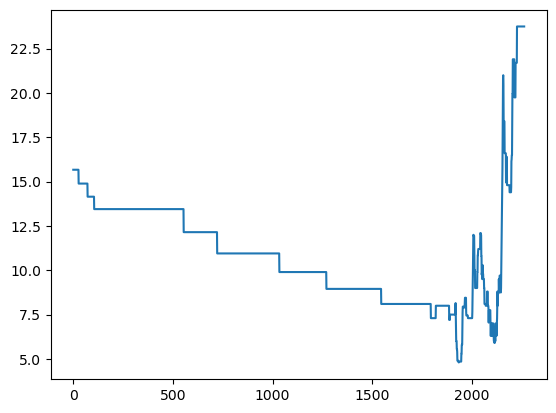

In [2]:
import matplotlib.pyplot as plt

plt.plot(uniondicon['close_price'])
plt.show()

In [3]:
uniondicon_end_month_df = (
    uniondicon
    .sort_values("date")
    .groupby(uniondicon["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

uniondicon_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45368,UNIONDICON,2017-01-31,15.67,15.67,0,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47189,UNIONDICON,2017-02-28,14.89,14.89,1000,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49305,UNIONDICON,2017-03-31,14.89,14.89,0,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51133,UNIONDICON,2017-04-28,14.15,14.15,0,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53055,UNIONDICON,2017-05-31,14.15,14.15,0,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35386,UNIONDICON,2026-03-31,14.40,14.40,135564,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281212,UNIONDICON,2026-04-30,21.90,21.90,33895,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284278,UNIONDICON,2026-05-29,23.75,23.75,15285,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294206,UNIONDICON,2026-06-30,23.75,23.75,2798,2026-06-30T15:10:03.08168+00:00,6,2,2026


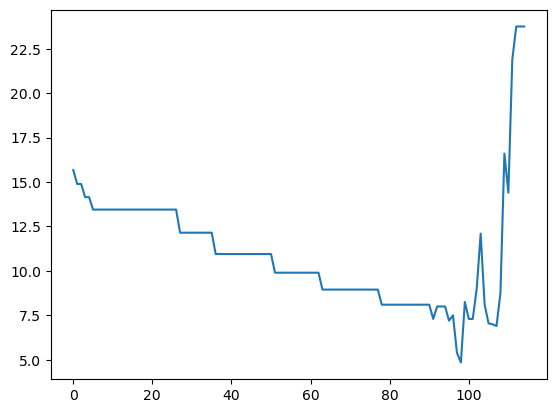

In [4]:
plt.plot(uniondicon_end_month_df['close_price'])
plt.show()

In [5]:
uniondicon_end_month_df['returns']=uniondicon_end_month_df['close_price'].pct_change()*100
uniondicon_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45368,UNIONDICON,2017-01-31,15.67,15.67,0,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47189,UNIONDICON,2017-02-28,14.89,14.89,1000,2026-04-08T02:44:45.006295+00:00,2,1,2017,-4.977664
2,49305,UNIONDICON,2017-03-31,14.89,14.89,0,2026-04-08T02:45:42.281198+00:00,3,1,2017,0.000000
3,51133,UNIONDICON,2017-04-28,14.15,14.15,0,2026-04-08T02:51:55.619599+00:00,4,2,2017,-4.969778
4,53055,UNIONDICON,2017-05-31,14.15,14.15,0,2026-04-08T02:52:57.421655+00:00,5,2,2017,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
110,35386,UNIONDICON,2026-03-31,14.40,14.40,135564,2026-03-31T15:00:02.085058+00:00,3,1,2026,-13.253012
111,281212,UNIONDICON,2026-04-30,21.90,21.90,33895,2026-04-30T15:00:02.170664+00:00,4,2,2026,52.083333
112,284278,UNIONDICON,2026-05-29,23.75,23.75,15285,2026-05-29T15:00:02.455558+00:00,5,2,2026,8.447489
113,294206,UNIONDICON,2026-06-30,23.75,23.75,2798,2026-06-30T15:10:03.08168+00:00,6,2,2026,0.000000


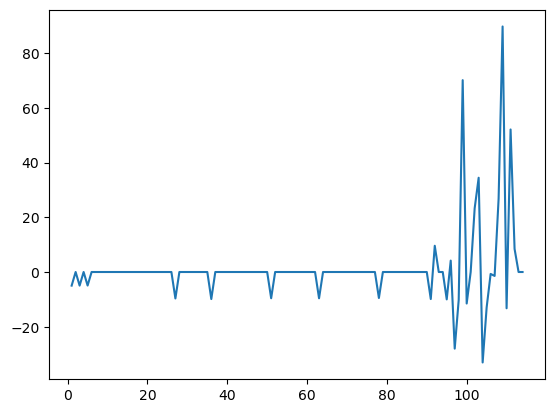

In [6]:
plt.plot(uniondicon_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(uniondicon_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(1.9374353873101835, 0.9985859239408554, 13, 100, {'1%': -3.497501033, '5%': -2.89090644, '10%': -2.5824349}, 773.2302249298162)
not stationary


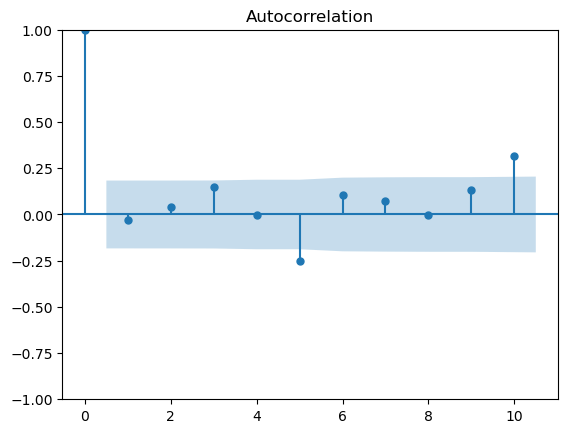

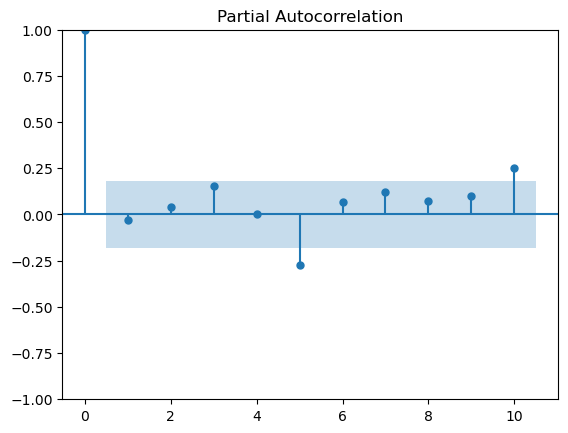

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(uniondicon_end_month_df['returns'].dropna(), lags=10)
plot_pacf(uniondicon_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=uniondicon_end_month_df['close_price'][:-10]
test=uniondicon_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -4.63559485928847]
[0, 0, 0, 0, 0, 1, -2.610973249413799]
[0, 0, 0, 0, 0, 2, -2.457518005768582]
[0, 0, 0, 0, 1, 0, -1.282146705828957]
[0, 0, 0, 0, 1, 1, -1.352697073341517]
[0, 0, 0, 0, 1, 2, -1.4296439256572282]
[0, 0, 0, 0, 2, 0, -1.6077864672834496]
[0, 0, 0, 0, 2, 1, -1.5537719859457333]
[0, 0, 0, 0, 2, 2, -1.5041589063792022]
[0, 0, 0, 1, 0, 0, -1.295008521733883]
[0, 0, 0, 1, 0, 1, -1.36679769340502]
[0, 0, 0, 1, 0, 2, -1.4450577509047737]
[0, 0, 0, 1, 1, 0, -1.440682988859292]
[0, 0, 0, 1, 1, 1, -1.4860191561865865]
[0, 0, 0, 1, 1, 2, -1.4347058121815626]
[0, 0, 0, 1, 2, 0, -1.543846965109028]
[0, 0, 0, 1, 2, 1, -1.528952695745477]
[0, 0, 0, 1, 2, 2, -1.5248293027051218]
[0, 0, 0, 2, 0, 0, -1.4579650068386538]
[0, 0, 0, 2, 0, 1, -1.4971692808677837]
[0, 0, 0, 2, 0, 2, -1.4632188648387023]
[0, 0, 0, 2, 1, 0, -1.462435925186771]
[0, 0, 0, 2, 1, 1, -1.4599506502682438]
[0, 0, 0, 2, 1, 2, -1.4517254167700608]
[0, 0, 0, 2, 2, 0, -1.5197180905209553]
[0, 0, 0, 2, 

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
453,1,2,1,2,1,0,-3.818513e+09
482,1,2,2,2,1,2,-5.038507e+06
696,2,2,1,2,1,0,-1.444338e+06
168,0,2,0,0,2,0,-3.765638e+01
169,0,2,0,0,2,1,-3.206287e+01
...,...,...,...,...,...,...,...
664,2,2,0,1,2,1,-3.789274e-01
665,2,2,0,1,2,2,-3.332415e-01
673,2,2,0,2,2,1,-2.625612e-01
672,2,2,0,2,2,0,-2.597094e-01


Its not capturing the variations properly. Lets try the returns

In [11]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=uniondicon_end_month_df['returns'].dropna()[:-10]
test=uniondicon_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.22828188953104722]
[0, 0, 0, 0, 0, 1, -0.6655521524097106]
[0, 0, 0, 0, 0, 2, -0.43554260656928756]
[0, 0, 0, 0, 1, 0, -0.6400532033977002]
[0, 0, 0, 0, 1, 1, -0.3436037896384645]
[0, 0, 0, 0, 1, 2, -0.3414362148700252]
[0, 0, 0, 0, 2, 0, -2.4133990378632704]
[0, 0, 0, 0, 2, 1, -1.3505346771932216]
[0, 0, 0, 0, 2, 2, -1.1978977699034523]
[0, 0, 0, 1, 0, 0, -0.37496491925138553]
[0, 0, 0, 1, 0, 1, -0.3860120722281679]
[0, 0, 0, 1, 0, 2, -0.40182936381736]
[0, 0, 0, 1, 1, 0, -0.3104693571190016]
[0, 0, 0, 1, 1, 1, -0.31726221222661777]
[0, 0, 0, 1, 1, 2, -0.3299965269939418]
[0, 0, 0, 1, 2, 0, -1.2461580087655775]
[0, 0, 0, 1, 2, 1, -1.0960804310222088]
[0, 0, 0, 1, 2, 2, -1.1245005302574178]
[0, 0, 0, 2, 0, 0, -0.3892123020332887]
[0, 0, 0, 2, 0, 1, -0.3784123723604975]
[0, 0, 0, 2, 0, 2, -0.38401077447465837]
[0, 0, 0, 2, 1, 0, -0.3202863689437705]
[0, 0, 0, 2, 1, 1, -0.32175901240400373]
[0, 0, 0, 2, 1, 2, -0.5853485030383045]
[0, 0, 0, 2, 2, 0, -1.02858252361078

In [12]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
168,0,2,0,0,2,0,-520.623189
188,0,2,0,2,2,2,-444.526186
169,0,2,0,0,2,1,-424.542196
170,0,2,0,0,2,2,-402.244126
177,0,2,0,1,2,0,-402.215458
...,...,...,...,...,...,...,...
687,2,2,1,1,1,0,0.010004
589,2,1,0,2,1,1,0.011319
579,2,1,0,1,1,0,0.015170
580,2,1,0,1,1,1,0.016618


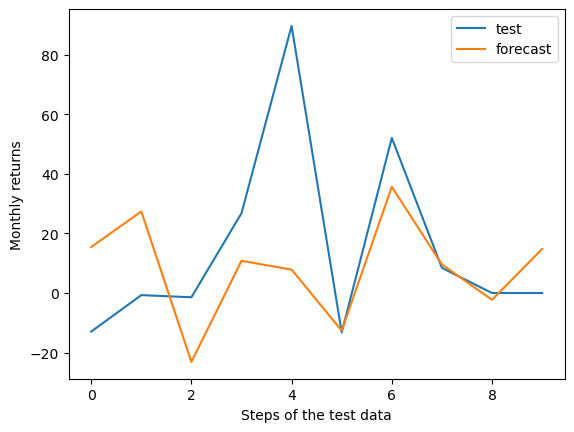

r2_score:  0.01744590426109416
rmse:  30.850488685570518
description:  count    114.000000
mean       1.092461
std       13.749998
min      -33.057851
25%        0.000000
50%        0.000000
75%        0.000000
max       89.714286
Name: returns, dtype: float64


In [13]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=uniondicon_end_month_df['returns'].dropna()[:-10]
y_test=uniondicon_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,1,0), 
seasonal_order=(2,1,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly returns')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', uniondicon_end_month_df.returns.dropna().describe())

Very horrible. We will work with it.
